In [1]:
# System related and data input controls
import os
import warnings
# Ignore the warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Library
import pandas as pd
import numpy as np
import math
import scipy.stats as stats  # 왜도(Skewness)와 첨도(Kurtosis) 계산을 위해 추가

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score # 평가 지표 추가

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

#--------------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve
)


# 데이터 상세:
| 파일 이름                | Date 단위   | 시작 연월 | 종료 연월   | 컬럼 수 | 행 수 |
|----------------------|-----------|--------|---------|------|-----|
| `df_KTX_monthsum_KK` | 월         | 2015-01| 2025-12 | 22   | 264 |
| `ECON_경제활동인구_KK`     | 월         | 2015-01| 2025-02 | 25   | 122 |
| `ECON_소비자동향조사`       | 월         | 2015-01| 2025-03 | 5    | 123 |
| `ECON_소비자물가지수_KK`    | 월         | 2015-01| 2025-02 | 29   | 122 |
| `KOSIS_내국인출국교통수단별_KK`| 월         | 2015-01| 2024-12 | 5    | 120 |
| `KOSIS_외래객_입국목적별_국적별_KK`| 월         | 2015-01| 2024-12 | 7    | 122 |
| `KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK`| 연 | 2015-01| 2024-01 | 13   | 10  |


#### KTX 데이터

In [2]:
RAW_DATA_PATH = '../raw_data/'

## KTX 데이터
df = pd.read_csv(RAW_DATA_PATH + 'df_KTX_monthsum_KK.csv')
df['Date'] = pd.to_datetime(df['Date'])

## 경부선 KTX만 사용
df = df[df['주운행선']=='경부선']


print(f" df -> df_KTX_monthsum : \n {df.columns}\n ")

 df -> df_KTX_monthsum : 
 Index(['전체주중주말', '주운행선', 'Date', '공급차량수', '공급좌석합계수', '승차인원수', '1인당단가', '1인당거리',
       '1좌석당단가', '좌석회전율', '1키로당단가', '승차율', '관광', '일반', '대수송', '임시', '확정',
       '시발역', '종착역', '시발종착역', '열차운행횟수', '1열차당승차인원'],
      dtype='object')
 


#### ECON 데이터

In [3]:
## Econ 데이터
df_active = pd.read_excel(RAW_DATA_PATH + 'ECON_경제활동인구_KK.xlsx', sheet_name='데이터', header=7)
df_active['Date'] = pd.to_datetime(df_active['Date'])
df_sentiment = pd.read_excel(RAW_DATA_PATH + 'ECON_소비자동향조사(전국, 월, 2008.9~)_KK.xlsx', sheet_name='데이터', header=7)
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'])
df_sentiment = df_sentiment.dropna(axis=1)
df_price = pd.read_excel(RAW_DATA_PATH + 'ECON_소비자물가지수_KK.xlsx', sheet_name='데이터', header=6)
df_price['Date'] = pd.to_datetime(df_price['Date'])
df_price.columns = df_price.columns.str.strip()  # 컬럼에 공백이 있음

print(f" df_active -> ECON_경제활동인구 : \n {df_active.columns}\n ")
print(f" df_sentiment -> ECON_소비자동향조사(전국, 월, 2008.9~) : \n {df_sentiment.columns}\n ")
print(f" df_price -> ECON_소비자물가지수 : \n {df_price.columns}\n ")

 df_active -> ECON_경제활동인구 : 
 Index(['Date', '경제활동인구_원자료', '경제활동인구_전기대비증감', '경제활동인구_전년동기대비증감',
       '경제활동인구_이동평균(3기간)', '  실업률_원자료', '  실업률_전기대비증감', '  실업률_전년동기대비증감',
       '  실업률_이동평균(3기간)', '15세이상인구_원자료', '15세이상인구_전기대비증감', '15세이상인구_전년동기대비증감',
       '15세이상인구_이동평균(3기간)', '비경제활동인구_원자료', '비경제활동인구_전기대비증감',
       '비경제활동인구_전년동기대비증감', '비경제활동인구_이동평균(3기간)', '경제활동참가율_원자료',
       '경제활동참가율_전기대비증감', '경제활동참가율_전년동기대비증감', '경제활동참가율_이동평균(3기간)', '고용률_원자료',
       '고용률_전기대비증감', '고용률_전년동기대비증감', '고용률_이동평균(3기간)'],
      dtype='object')
 
 df_sentiment -> ECON_소비자동향조사(전국, 월, 2008.9~) : 
 Index(['Date', '소비자심리지수_원자료', '소비자심리지수_전기대비증감', '소비자심리지수_전년동기대비증감',
       '소비자심리지수_이동평균(3기간)'],
      dtype='object')
 
 df_price -> ECON_소비자물가지수 : 
 Index(['Date', '총지수_원자료', '총지수_전기대비증감', '총지수_전년동기대비증감', '총지수_이동평균(3기간)',
       '운송장비_원자료', '운송장비_전기대비증감', '운송장비_전년동기대비증감', '운송장비_이동평균(3기간)',
       '개인운송장비 운영_원자료', '개인운송장비 운영_전기대비증감', '개인운송장비 운영_전년동기대비증감',
       '개인운송장비 운영_이동평균(3기간)', '철도 여객수송_원자료', '철도 여객수송_전기대비증감',


In [4]:
## Kosis 데이터
df_traffic = pd.read_csv(RAW_DATA_PATH + 'KOSIS_내국인출국교통수단별_KK.csv', encoding='cp949', header=2)
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])
df_traffic['내국인출입국_공항'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '공항']].sum(axis=1).values
df_traffic['내국인출입국_항구'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '항구']].sum(axis=1).values
df_traffic.drop(columns=[col for col in df_traffic.columns if col.split('_')[0] in ['공항', '항구']], inplace=True)
df_entry = pd.read_csv(RAW_DATA_PATH + 'KOSIS_외래객_입국목적별_국적별_KK.csv', encoding='cp949', header=1)
df_entry['Date'] = pd.to_datetime(df_entry['Date'])
df_population = pd.read_csv(RAW_DATA_PATH + 'KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK.csv', encoding='cp949', header=0)
df_population['Date'] = pd.to_datetime(df_population['Date'], format='%Y', errors='coerce')
df_population = df_population[[col for col in df_population.columns if col not in ['영아사망률(출생아 천명당)', '기대수명(출생시 기대여명)',
                                                                                   '기대수명(출생시 기대여명) - 남', '기대수명(출생시 기대여명) - 여']]]

print(f" df_traffic -> KOSIS_내국인출국교통수단별 : \n {df_traffic.columns}\n ")
print(f" df_entry -> KOSIS_외래객_입국목적별_국적별 : \n {df_entry.columns}\n ")
print(f" df_population -> KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼 : \n {df_population.columns}\n ")

 df_traffic -> KOSIS_내국인출국교통수단별 : 
 Index(['Date', '내국인출입국_전체', '내국인출입국_공항', '내국인출입국_항구'], dtype='object')
 
 df_entry -> KOSIS_외래객_입국목적별_국적별 : 
 Index(['Date', '외래객입국사유_전체', '외래객입국사유_관광', '외래객입국사유_상용', '외래객입국사유_공융',
       '외래객입국사유_유학연수', '외래객입국사유_기타'],
      dtype='object')
 
 df_population -> KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼 : 
 Index(['Date', '출생아수(명)', '사망자수(명)', '자연증가건수(명)', '조출생률(천명당)', '조사망률(천명당)',
       '자연증가율(천명당)', '합계출산율(명)', '출생성비(명)', '혼인건수(건)', '조혼인율(천명당)', '이혼건수(건)',
       '조이혼율(천명당)'],
      dtype='object')
 


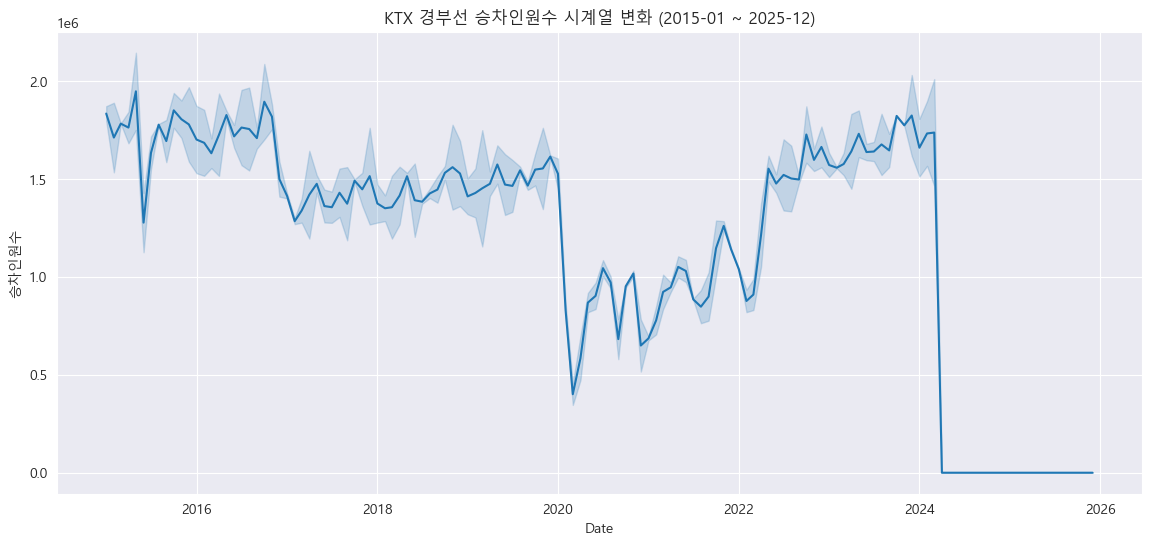

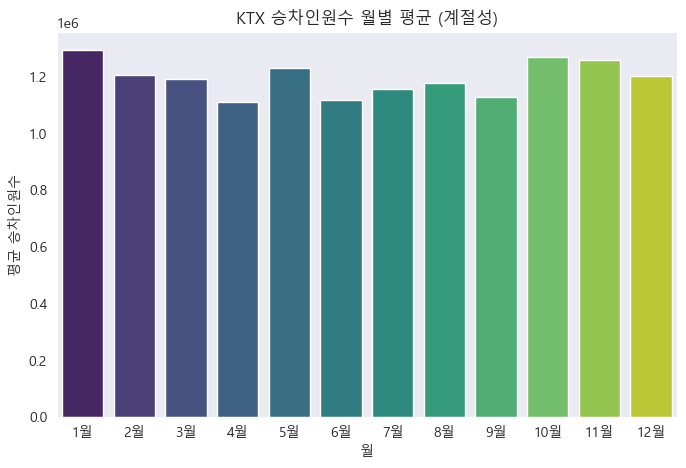

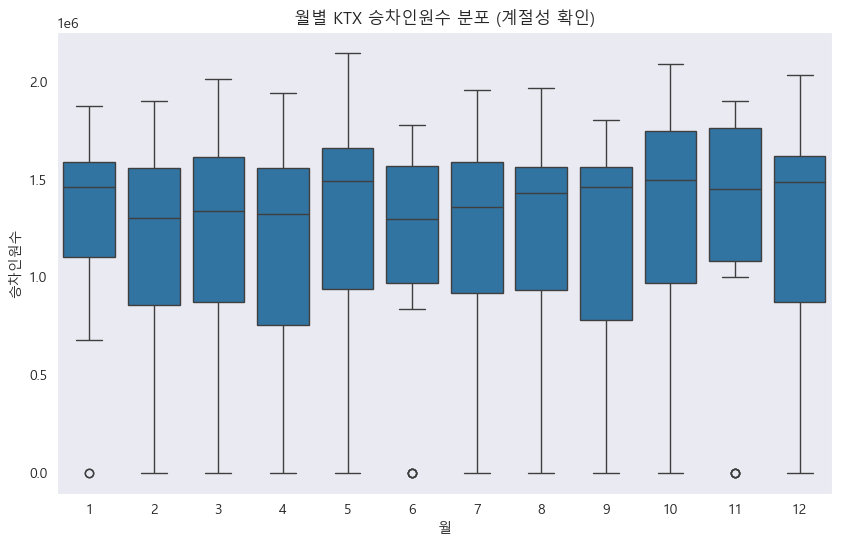

### KTX 승차인원수 주요 통계량 ###
count    2.640000e+02
mean     1.193699e+06
std      6.135753e+05
min      0.000000e+00
25%      9.211645e+05
50%      1.427504e+06
75%      1.617264e+06
max      2.144330e+06
Name: 승차인원수, dtype: float64


In [5]:
# 시계열 시각화
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='승차인원수')
plt.title('KTX 경부선 승차인원수 시계열 변화 (2015-01 ~ 2025-12)')
plt.xlabel('Date')
plt.ylabel('승차인원수')
plt.grid(True)
plt.show()

# 월별 평균 승차인원수 (계절성 확인)
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['승차인원수'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis')
plt.title('KTX 승차인원수 월별 평균 (계절성)')
plt.xlabel('월')
plt.ylabel('평균 승차인원수')
plt.xticks(range(12), ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월'])
plt.grid(axis='y')
plt.show()

# 월별 승차인원 상자 그림 (계절성 분석)
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(10, 6))
sns.boxplot(x='Month', y='승차인원수', data=df)
plt.title('월별 KTX 승차인원수 분포 (계절성 확인)')
plt.xlabel('월')
plt.ylabel('승차인원수')
plt.grid(axis='y')
plt.show()

# KTX 수요 주요 통계량
print("### KTX 승차인원수 주요 통계량 ###")
print(df['승차인원수'].describe())

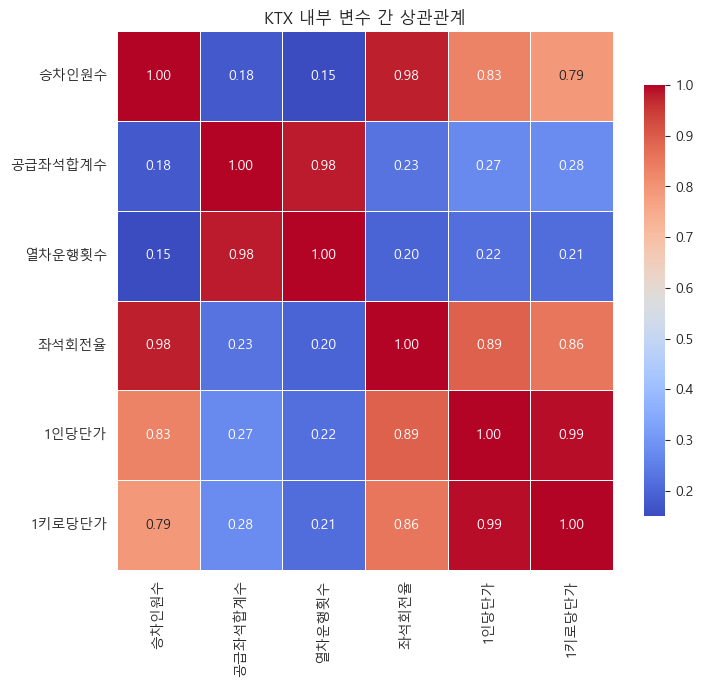

In [6]:
# KTX 내부 주요 변수들 선택
ktx_cols = ['승차인원수', '공급좌석합계수', '열차운행횟수', '좌석회전율', '1인당단가', '1키로당단가']
corr_matrix_ktx = df[ktx_cols].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix_ktx, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'shrink': 0.8})
plt.title('KTX 내부 변수 간 상관관계')
plt.show()

In [7]:
df_merged = df[['Date', '승차인원수']].copy()

# 1. 경제 활동 인구 (df_active) 병합
# '  실업률_원자료' 등에도 공백이 있으므로 병합 전에 컬럼 정리 필요
df_active.columns = df_active.columns.str.strip().str.replace(' ', '_', regex=False)
df_merged = df_merged.merge(df_active[['Date', '경제활동인구_원자료', '고용률_원자료']], on='Date', how='left')

# 2. 소비자 심리 (df_sentiment) 병합
df_merged = df_merged.merge(df_sentiment[['Date', '소비자심리지수_원자료']], on='Date', how='left')

# 3. 소비자 물가지수 (df_price) 병합 - 이미 컬럼 정리 완료됨
# 정리된 컬럼 이름: '총지수_원자료', '철도 여객수송_원자료', '도로 여객수송_원자료' (공백을 언더바로 바꾸지 않았다면)
# 현재 컬럼명을 다시 확인하여 공백을 처리합니다.
df_price.columns = df_price.columns.str.strip()
df_price.columns = df_price.columns.str.replace(' ', '_', regex=False) # 언더바로 대체하여 통일
df_merged = df_merged.merge(df_price[['Date', '총지수_원자료', '철도_여객수송_원자료', '도로_여객수송_원자료']], on='Date', how='left')

# 4. 내국인 출국 (df_traffic) 병합
df_merged = df_merged.merge(df_traffic[['Date', '내국인출입국_전체']], on='Date', how='left')

# 5. 외래객 입국 (df_entry) 병합
df_merged = df_merged.merge(df_entry[['Date', '외래객입국사유_전체', '외래객입국사유_관광']], on='Date', how='left')

# 병합 결과 확인
print("✅ 데이터프레임 최종 병합 후 상위 5개 행:")
print(df_merged.head())
print("\n병합된 데이터프레임의 결측치(NaN) 개수:")
print(df_merged.isnull().sum())

✅ 데이터프레임 최종 병합 후 상위 5개 행:
        Date    승차인원수  경제활동인구_원자료  고용률_원자료  소비자심리지수_원자료  총지수_원자료  철도_여객수송_원자료  \
0 2015-01-01  1871129     26380.0     59.0        103.2   94.643       91.619   
1 2015-02-01  1533571     26671.0     59.1        103.9   94.587       91.619   
2 2015-03-01  1780862     26840.0     59.8        102.0   94.596       91.619   
3 2015-04-01  1681821     27204.0     60.6        104.9   94.625       91.619   
4 2015-05-01  2144330     27453.0     61.2        106.3   94.890       91.619   

   도로_여객수송_원자료  내국인출입국_전체  외래객입국사유_전체  외래객입국사유_관광  
0       85.896  1834538.0    917054.0    723255.0  
1       85.896  1445609.0   1050706.0    815138.0  
2       85.896  1416683.0   1238144.0    958493.0  
3       85.896  1495460.0   1384567.0   1112904.0  
4       85.896  1579265.0   1334212.0   1060730.0  

병합된 데이터프레임의 결측치(NaN) 개수:
Date            0
승차인원수           0
경제활동인구_원자료     20
고용률_원자료        20
소비자심리지수_원자료    18
총지수_원자료        20
철도_여객수송_원자료    20
도로_여객수송_원자료    20
내국인출입

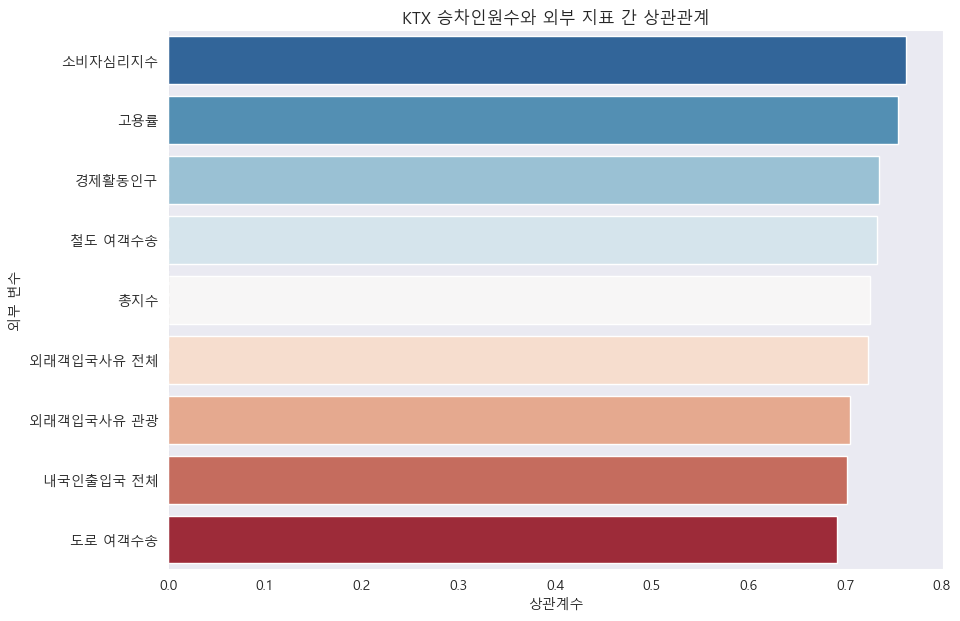

In [8]:
# KTX 수요와 외부 변수 간 상관관계 분석을 위한 컬럼 선택
external_cols = [
    '승차인원수',
    '경제활동인구_원자료', '고용률_원자료',
    '소비자심리지수_원자료',
    '총지수_원자료', '철도_여객수송_원자료', '도로_여객수송_원자료',
    '내국인출입국_전체',
    '외래객입국사유_전체', '외래객입국사유_관광'
]

# 결측치 제거 후 상관관계 계산 (기간 불일치로 인한 NaN 제거)
df_corr = df_merged[external_cols].dropna()

# 상관관계 행렬 계산
corr_matrix_external = df_corr.corr()

# '승차인원수'와의 상관계수만 추출
correlation_with_demand = corr_matrix_external['승차인원수'].sort_values(ascending=False).drop('승차인원수')

plt.figure(figsize=(10, 7))
sns.barplot(x=correlation_with_demand.values, y=correlation_with_demand.index.str.replace('_원자료', '').str.replace('_', ' '), palette='RdBu_r')
plt.title('KTX 승차인원수와 외부 지표 간 상관관계')
plt.xlabel('상관계수')
plt.ylabel('외부 변수')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(axis='x')
plt.show()

In [9]:
# df_KTX_monthsum_KK에 Year, Month 컬럼 추가
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 1. 시계열 모델링을 위한 기본 변수 생성
df_merged['Year'] = df_merged['Date'].dt.year
df_merged['Month'] = df_merged['Date'].dt.month

In [ ]:
import pandas as pd

# 1. df_population_yearly에 'Date' 컬럼 재정의 (각 연도의 마지막 날로 설정)
# 보간을 위해 시계열 인덱스가 필요합니다.
df_population_yearly['Date'] = pd.to_datetime(df_population_yearly['Year'].astype(str) + '-12-31')
df_population_yearly = df_population_yearly.set_index('Date').sort_index()

# 2. 월별 데이터프레임으로 변환 (리샘플링)
# 연간 값은 해당 연도의 마지막 날에만 존재하고, 나머지는 NaN이 됩니다.
monthly_series = df_population_yearly[['출생아수_명', '혼인건수_건']].resample('M').ffill()

# 3. 선형 보간 (Linear Interpolation) 적용
# NaN 값을 이전 연도 값과 다음 연도 값 사이의 직선으로 채웁니다.
interpolated_monthly = monthly_series.interpolate(method='linear')

# 4. 일별 평균으로 변환
# 보간된 값은 여전히 연간 총계의 개념이므로, 이를 일 단위 일수로 나누어 '월별 평균 추정치'를 계산합니다.
interpolated_monthly['월별_선형보간_출생'] = interpolated_monthly['출생아수_명'] / 12
interpolated_monthly['월별_선형보간_혼  인'] = interpolated_monthly['혼인건수_건'] / 12

# Year를 기준으로 df_merged에 병합
interpolated_monthly['Year'] = interpolated_monthly.index.year
df_merged = df_merged.merge(
    interpolated_monthly[['Year', '월별_선형보간_출생', '월별_선형보간_혼인']].drop_duplicates(subset=['Year']),
    on='Year',
    how='left'
)

print("\n✅ 선형 보간 데이터 병합 후 데이터 확인:")
print(df_merged[['Date', 'Year', '월별_선형보간_출생', '월별_선형보간_혼인']].head())

In [10]:
# KOSIS_인구동태건수_및_동태율_추이 (df_population) 컬럼 정리
df_population.columns = df_population.columns.str.strip().str.replace('(', '_', regex=False).str.replace(')', '', regex=False)

# 연 단위 데이터를 월 단위 데이터에 매핑
df_population['Year'] = df_population['Date'].dt.year

# 월 평균 지표 계산
df_population_yearly = df_population[['Year', '출생아수_명', '혼인건수_건']].copy()
df_population_yearly['월평균_출생아수'] = df_population_yearly['출생아수_명'] / 12
df_population_yearly['월평균_혼인건수'] = df_population_yearly['혼인건수_건'] / 12


# Year를 기준으로 df_merged에 병합
df_merged = df_merged.merge(df_population_yearly, on='Year', how='left')

print("\n✅ 인구 데이터 병합 후 데이터 확인:")
print(df_merged[['Date', 'Year', '출생아수_명', '혼인건수_건']].head())


✅ 인구 데이터 병합 후 데이터 확인:
        Date  Year    출생아수_명    혼인건수_건
0 2015-01-01  2015  438420.0  302828.0
1 2015-02-01  2015  438420.0  302828.0
2 2015-03-01  2015  438420.0  302828.0
3 2015-04-01  2015  438420.0  302828.0
4 2015-05-01  2015  438420.0  302828.0


In [11]:
# KTX 원본 데이터(df_KTX_monthsum_KK)를 활용하여 특성 생성 후 df_merged에 병합

# KTX 데이터프레임의 컬럼 이름 정리 (이전에 놓친 공백 처리)
df.columns = df.columns.str.strip()

# df_KTX_features: KTX 원본 데이터에서 필요한 컬럼만 추출하여 복사
df_KTX_features = df[['Date', '1인당단가', '공급차량수', '관광', '승차인원수']].copy()

# 1. '가격_경쟁력' 생성을 위해 df_price의 '총지수_원자료' 병합
df_price.columns = df_price.columns.str.strip().str.replace(' ', '_', regex=False)
df_KTX_features = df_KTX_features.merge(df_price[['Date', '총지수_원자료']], on='Date', how='left')

# 2. 특성 생성
df_KTX_features['가격_경쟁력'] = df_KTX_features['1인당단가'] / df_KTX_features['총지수_원자료']
df_KTX_features['운영_효율'] = df_KTX_features['승차인원수'] / df_KTX_features['공급차량수']
df_KTX_features['관광_비율'] = df_KTX_features['관광'] / df_KTX_features['승차인원수']

# 3. df_merged에 새로운 특성 병합
new_features = df_KTX_features[['Date', '가격_경쟁력', '운영_효율', '관광_비율']]
df_merged = df_merged.merge(new_features, on='Date', how='left')

print("✅ KTX 내부 기반 특성 생성 완료. '가격_경쟁력', '운영_효율', '관광_비율' 추가:")
print(df_merged[['Date', '가격_경쟁력', '운영_효율', '관광_비율']].tail())

✅ KTX 내부 기반 특성 생성 완료. '가격_경쟁력', '운영_효율', '관광_비율' 추가:
          Date  가격_경쟁력  운영_효율  관광_비율
523 2025-10-01     NaN    NaN    NaN
524 2025-11-01     NaN    NaN    NaN
525 2025-11-01     NaN    NaN    NaN
526 2025-12-01     NaN    NaN    NaN
527 2025-12-01     NaN    NaN    NaN


In [12]:
# 'Date'를 인덱스로 설정하여 시계열 연산 수행
df_merged = df_merged.set_index('Date').sort_index()

# 1. Lag Features (시차 특성)
df_merged['Lag_1_승차인원수'] = df_merged['승차인원수'].shift(1)
df_merged['Lag_12_승차인원수'] = df_merged['승차인원수'].shift(12)

# 2. Rolling Window Features (이동 평균)
# 3개월 이동평균 (이동 창을 포함한 기간의 평균을 구함)
df_merged['3개월_이동평균'] = df_merged['승차인원수'].rolling(window=3).mean().shift(1) # 예측 시점 이전에 계산된 값만 사용하기 위해 shift(1) 적용

# 3. Year-over-Year Change (전년 대비 변화율)
# (현재 값 - 12개월 전 값) / 12개월 전 값
df_merged['YOY_승차인원수'] = (df_merged['승차인원수'] - df_merged['Lag_12_승차인원수']) / df_merged['Lag_12_승차인원수']

# 인덱스 초기화
df_merged = df_merged.reset_index()

print("✅ 시계열 특성 생성 완료. Lag, 이동평균, YOY 추가:")
print(df_merged[['Date', '승차인원수', 'Lag_1_승차인원수', '3개월_이동평균', 'YOY_승차인원수']].tail(15))

✅ 시계열 특성 생성 완료. Lag, 이동평균, YOY 추가:
          Date  승차인원수  Lag_1_승차인원수  3개월_이동평균  YOY_승차인원수
513 2025-09-01      0          0.0       0.0        NaN
514 2025-09-01      0          0.0       0.0        NaN
515 2025-09-01      0          0.0       0.0        NaN
516 2025-10-01      0          0.0       0.0        NaN
517 2025-10-01      0          0.0       0.0        NaN
518 2025-10-01      0          0.0       0.0        NaN
519 2025-10-01      0          0.0       0.0        NaN
520 2025-11-01      0          0.0       0.0        NaN
521 2025-11-01      0          0.0       0.0        NaN
522 2025-11-01      0          0.0       0.0        NaN
523 2025-11-01      0          0.0       0.0        NaN
524 2025-12-01      0          0.0       0.0        NaN
525 2025-12-01      0          0.0       0.0        NaN
526 2025-12-01      0          0.0       0.0        NaN
527 2025-12-01      0          0.0       0.0        NaN


In [13]:
import holidays
from pandas.tseries.offsets import MonthEnd # 해당 월의 마지막 날짜를 구하기 위해 import

# 1. 대한민국 공휴일 데이터 로드 (2015년 ~ 2025년)
kr_holidays = holidays.KR(years=range(2015, 2026))

# 2. 'Date' 인덱스 초기화 (앞선 단계에서 인덱스 설정되었을 경우)
if 'Date' in df_merged.index.names:
    df_merged = df_merged.reset_index()

# 3. 'Date' 컬럼의 기간을 추출하여 공휴일 카운트 함수 적용
def count_weekday_holidays_fixed(date, kr_holidays):
    """주어진 월의 평일 공휴일 개수를 계산합니다. (pd.date_range 호환성 문제 해결)"""

    # start_date: 해당 월의 1일
    start_date = pd.to_datetime(f'{date.year}-{date.month}-01')

    # end_date: 해당 월의 마지막 날 (MonthEnd 사용)
    end_date = start_date + MonthEnd(0)

    # 해당 월의 모든 날짜 생성 (end=end_date이므로 마지막 날 포함)
    # pd.date_range에서 closed/inclusive 대신 end=last day of month 사용
    dates_in_month = pd.date_range(start=start_date, end=end_date, freq='D')

    weekday_holiday_count = 0

    for day in dates_in_month:
        # 1. 공휴일인지 확인
        if day in kr_holidays:
            # 2. 평일(월요일=0, 금요일=4)인지 확인 (토요일=5, 일요일=6 제외)
            if day.weekday() < 5:
                weekday_holiday_count += 1

    return weekday_holiday_count

# 4. df_merged에 '공휴일_수' 컬럼 추가
df_merged['공휴일_수'] = df_merged['Date'].apply(lambda x: count_weekday_holidays_fixed(x, kr_holidays))

print("✅ '공휴일_수' 특성 추가 완료. (평일 공휴일만 카운트)")
print(df_merged[['Date', 'Year', 'Month', '주말_수', '공휴일_수']].tail(15))

✅ '공휴일_수' 특성 추가 완료. (평일 공휴일만 카운트)


KeyError: "['주말_수'] not in index"